# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding (CRISP-DM)

**Business objective:** Help a used-car dealership fine-tune inventory and pricing by understanding what vehicle attributes customers value (i.e., what drives **higher** or **lower** prices).

**Data mining problem (CRISP-DM translation):** Treat **price** as the target variable and vehicle attributes (e.g., age/year, odometer, condition, title status, fuel, transmission, drive, type, make/model, location) as predictors. This is a **supervised regression** task where we will (1) build predictive models, (2) quantify the marginal impact of features (interpretable coefficients / importances), and (3) evaluate generalization performance using an appropriate error metric.

**Success criteria:** A model that generalizes well (low out-of-sample error) *and* produces actionable, interpretable insights that a dealer can use to guide inventory selection and pricing.

In [8]:
# --- Setup / Imports ---
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure scikit-learn is available in the environment
try:
    import sklearn  # noqa: F401
except ModuleNotFoundError:
    !{sys.executable} -m pip install -q scikit-learn

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 200)

In [9]:
# --- Load data ---
# This notebook expects the repository structure:
#   data/vehicles.csv
data_path = Path("data/vehicles.csv")
df = pd.read_csv(data_path)

df.shape, df.head()

((426880, 18),
            id                  region  price  year manufacturer model  \
 0  7222695916                prescott   6000   NaN          NaN   NaN   
 1  7218891961            fayetteville  11900   NaN          NaN   NaN   
 2  7221797935            florida keys  21000   NaN          NaN   NaN   
 3  7222270760  worcester / central MA   1500   NaN          NaN   NaN   
 4  7210384030              greensboro   4900   NaN          NaN   NaN   
 
   condition cylinders fuel  odometer title_status transmission  VIN drive  \
 0       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
 1       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
 2       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
 3       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
 4       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
 
   size type paint_color state  
 0  NaN  NaN         NaN    az  
 1 

In [10]:
# --- Quick data overview ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [11]:
# Missingness (top 20)
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

size            0.717675
cylinders       0.416225
condition       0.407852
VIN             0.377254
drive           0.305863
paint_color     0.305011
type            0.217527
manufacturer    0.041337
title_status    0.019308
model           0.012362
odometer        0.010307
fuel            0.007058
transmission    0.005988
year            0.002823
region          0.000000
id              0.000000
price           0.000000
state           0.000000
dtype: float64

### Data Understanding

In CRISP-DM, **Data Understanding** focuses on acquiring the data, describing it, and performing initial exploration to spot quality issues. For this dataset, we will:

- Inspect shape, data types, and missingness patterns.
- Review distributions of `price`, `year`, `odometer`, and other numeric variables (and consider transformations like `log(price)` if the distribution is highly skewed).
- Explore key relationships with `price` using visualizations:
  - Numeric vs price (e.g., odometer, age)
  - Categorical vs price (e.g., condition, title status, fuel, transmission, drive, type, manufacturer)
- Identify data quality issues (missing values, outliers, impossible values, rare categories) that could bias the analysis or break modeling.

This exploration will inform which variables are most promising and what cleaning / preparation is required before modeling.

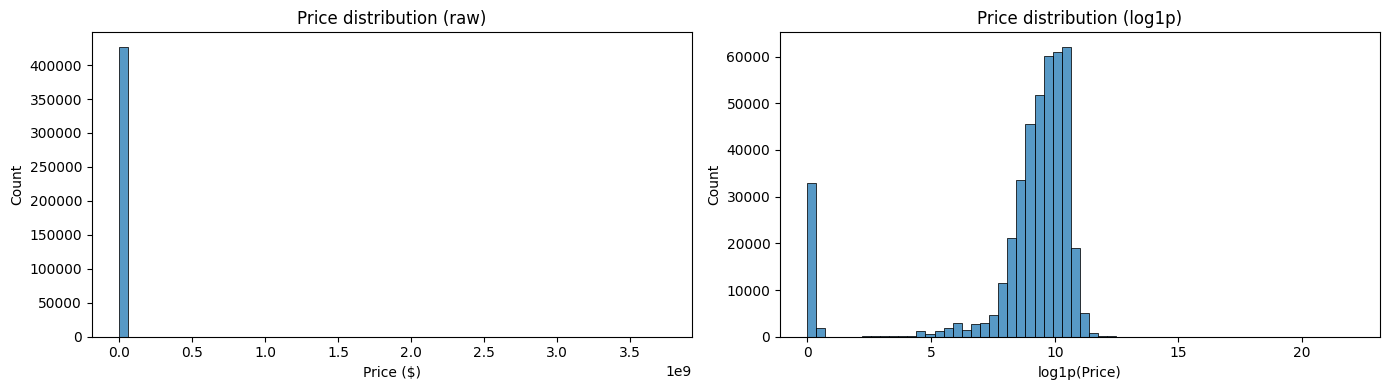

In [12]:
# Price distribution (raw) and log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["price"].dropna(), bins=60, ax=axes[0])
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price ($)")

sns.histplot(np.log1p(df["price"].dropna()), bins=60, ax=axes[1])
axes[1].set_title("Price distribution (log1p)")
axes[1].set_xlabel("log1p(Price)")

plt.tight_layout()
plt.show()

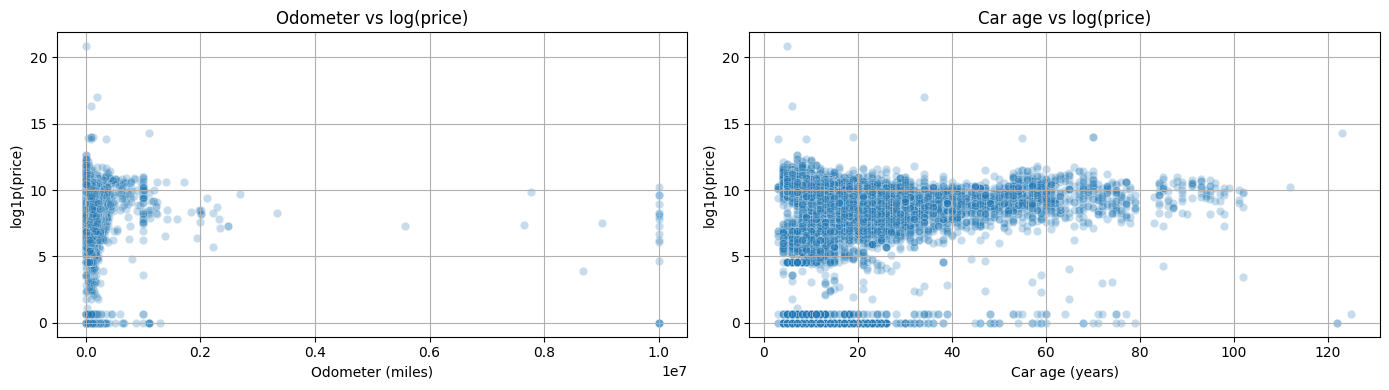

In [13]:
# Explore numeric relationships with price (sample for plotting speed)
plot_df = df.sample(min(50000, len(df)), random_state=42)

# Create car age if year exists
current_year = 2025
if "year" in plot_df.columns:
    plot_df = plot_df[plot_df["year"].notna()].copy()
    plot_df["car_age"] = current_year - plot_df["year"]

plot_df["log_price"] = np.log1p(plot_df["price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if "odometer" in plot_df.columns:
    sns.scatterplot(data=plot_df, x="odometer", y="log_price", alpha=0.25, ax=axes[0])
    axes[0].set_title("Odometer vs log(price)")
    axes[0].set_xlabel("Odometer (miles)")
    axes[0].set_ylabel("log1p(price)")
    axes[0].grid(True)

if "car_age" in plot_df.columns:
    sns.scatterplot(data=plot_df, x="car_age", y="log_price", alpha=0.25, ax=axes[1])
    axes[1].set_title("Car age vs log(price)")
    axes[1].set_xlabel("Car age (years)")
    axes[1].set_ylabel("log1p(price)")
    axes[1].grid(True)

plt.tight_layout()
plt.show()

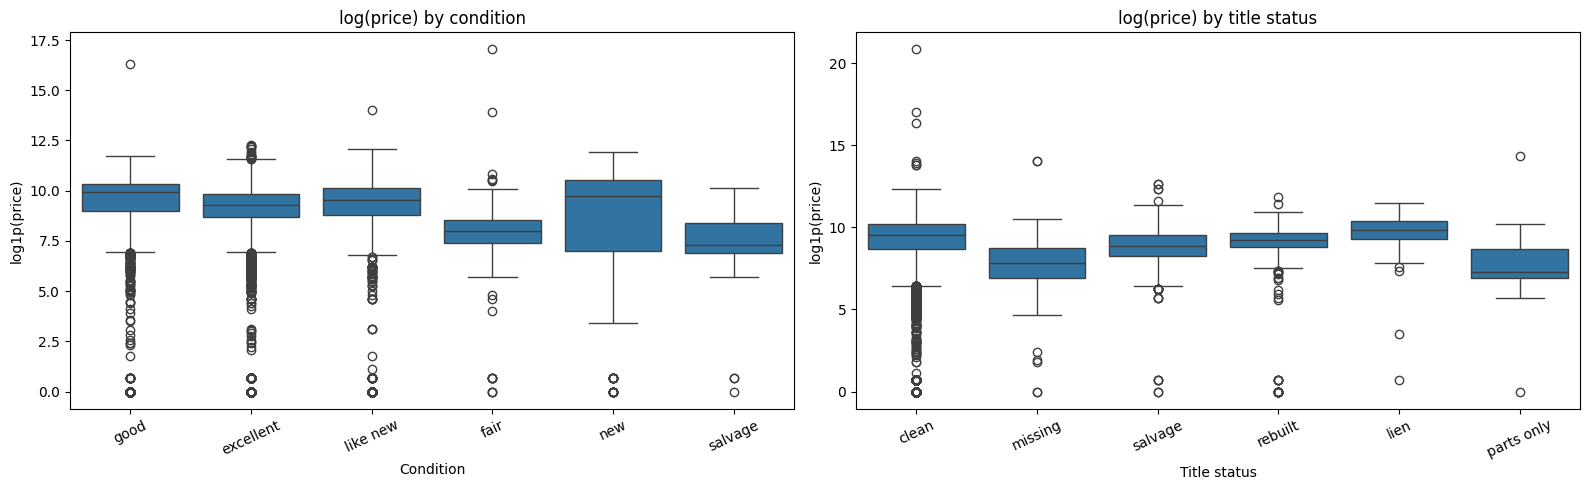

In [14]:
# Categorical vs price: Condition and title status (boxplots)
plot_df = df.sample(min(50000, len(df)), random_state=42).copy()
plot_df["log_price"] = np.log1p(plot_df["price"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if "condition" in plot_df.columns:
    sns.boxplot(data=plot_df[plot_df["condition"].notna()], x="condition", y="log_price", ax=axes[0])
    axes[0].set_title("log(price) by condition")
    axes[0].set_xlabel("Condition")
    axes[0].set_ylabel("log1p(price)")
    axes[0].tick_params(axis="x", rotation=25)

if "title_status" in plot_df.columns:
    sns.boxplot(data=plot_df[plot_df["title_status"].notna()], x="title_status", y="log_price", ax=axes[1])
    axes[1].set_title("log(price) by title status")
    axes[1].set_xlabel("Title status")
    axes[1].set_ylabel("log1p(price)")
    axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

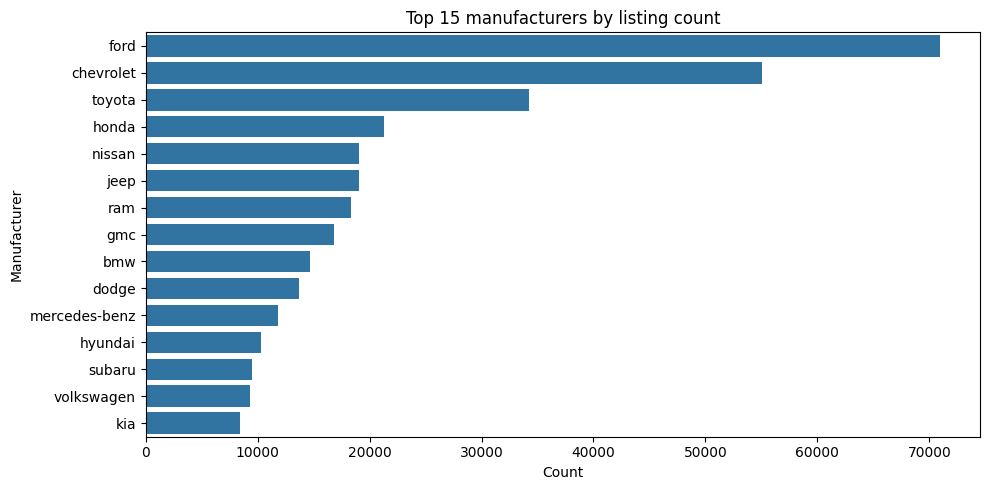

In [15]:
# Top manufacturers by count (helps spot rare categories)
if "manufacturer" in df.columns:
    top_makes = df["manufacturer"].value_counts().head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_makes.values, y=top_makes.index)
    plt.title("Top 15 manufacturers by listing count")
    plt.xlabel("Count")
    plt.ylabel("Manufacturer")
    plt.tight_layout()
    plt.show()

### Data Preparation

In CRISP-DM, **Data Preparation** is typically the most time-consuming phase. Here we will:

- Remove duplicates and obviously invalid records (e.g., non-positive prices, impossible years, negative odometer).
- Handle missing values:
  - Numeric: median imputation
  - Categorical: most-frequent imputation
- Engineer useful features such as **car age** (`current_year - year`) and optionally `log1p(price)` to stabilize variance.
- Prepare the dataset for scikit-learn using a **ColumnTransformer**:
  - One-hot encode categorical features
  - Scale numeric features for linear/regularized models

The output of this phase is a clean, model-ready feature matrix `X` and target `y`, along with reproducible preprocessing steps.

In [16]:
# --- Data preparation / cleaning ---
df_clean = df.drop_duplicates().copy()

# Remove invalid prices
df_clean = df_clean[df_clean["price"].between(500, 200000)]

# Create car_age and remove weird years / ages
current_year = 2025
if "year" in df_clean.columns:
    df_clean = df_clean[df_clean["year"].between(1980, 2026)]
    df_clean["car_age"] = current_year - df_clean["year"]
    df_clean = df_clean[df_clean["car_age"].between(0, 45)]
else:
    df_clean["car_age"] = np.nan

# Remove negative odometer if present
if "odometer" in df_clean.columns:
    df_clean = df_clean[df_clean["odometer"].isna() | (df_clean["odometer"] >= 0)]

df_clean.shape

(375490, 19)

In [17]:
# Define target and feature set
y = np.log1p(df_clean["price"])  # model log-price for stability
X = df_clean.drop(columns=["price"])

candidate_cols = [
    "car_age","odometer","manufacturer","model","condition","cylinders",
    "fuel","title_status","transmission","drive","type","paint_color","state"
]
candidate_cols = [c for c in candidate_cols if c in X.columns]
X = X[candidate_cols]

X.head(), y.head()

(    car_age  odometer manufacturer                     model  condition  \
 27     11.0   57923.0          gmc  sierra 1500 crew cab slt       good   
 28     15.0   71229.0    chevrolet            silverado 1500       good   
 29      5.0   19160.0    chevrolet       silverado 1500 crew       good   
 30      8.0   41124.0       toyota      tundra double cab sr       good   
 31     12.0  128000.0         ford                 f-150 xlt  excellent   
 
       cylinders fuel title_status transmission drive    type paint_color state  
 27  8 cylinders  gas        clean        other   NaN  pickup       white    al  
 28  8 cylinders  gas        clean        other   NaN  pickup        blue    al  
 29  8 cylinders  gas        clean        other   NaN  pickup         red    al  
 30  8 cylinders  gas        clean        other   NaN  pickup         red    al  
 31  6 cylinders  gas        clean    automatic   rwd   truck       black    al  ,
 27    10.422013
 28    10.025307
 29    10.58635

In [18]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((300392, 13), (75098, 13))

In [19]:
# Preprocessing: impute + scale numeric; impute + one-hot encode categoricals
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

cat_cols, num_cols

(['manufacturer',
  'model',
  'condition',
  'cylinders',
  'fuel',
  'title_status',
  'transmission',
  'drive',
  'type',
  'paint_color',
  'state'],
 ['car_age', 'odometer'])

In [20]:
# CV configuration and helper
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model, X, y):
    scores = cross_val_score(
        model, X, y,
        scoring="neg_root_mean_squared_error",
        cv=cv
    )
    return -scores.mean(), scores.std()

### Modeling

We will build multiple regression models to predict vehicle prices and compare performance using cross-validation:

1. **Baseline** (DummyRegressor) to establish a minimum standard.
2. **Linear Regression** as an interpretable reference model.
3. **Ridge / Lasso** (regularized linear models) with **GridSearchCV** to reduce overfitting and improve stability.
4. **Random Forest Regressor** (nonlinear model) with a small grid search to capture complex interactions.

We will evaluate models using **RMSE** on `log1p(price)` (and optionally interpret results back on the dollar scale). RMSE is a good fit here because pricing errors are costly and RMSE penalizes large misses more heavily than MAE.

In [22]:
# --- Baseline + Linear Regression ---
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="median"))
])
base_mean, base_std = rmse_cv(baseline, X_train, y_train)

lin = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
lin_mean, lin_std = rmse_cv(lin, X_train, y_train)

base_mean, lin_mean

(np.float64(0.9127237002192292), np.float64(0.4798892357162575))

In [23]:
# --- Ridge / Lasso with GridSearchCV ---
ridge = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])
ridge_grid = {"model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_gs = GridSearchCV(
    ridge, ridge_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)
ridge_gs.fit(X_train, y_train)

lasso = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(max_iter=20000))
])
lasso_grid = {"model__alpha": [0.0005, 0.001, 0.005, 0.01, 0.05]}
lasso_gs = GridSearchCV(
    lasso, lasso_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)
lasso_gs.fit(X_train, y_train)

ridge_gs.best_params_, lasso_gs.best_params_

({'model__alpha': 0.1}, {'model__alpha': 0.0005})

In [25]:
# --- Random Forest with modest GridSearchCV ---
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])
rf_grid = {
    "model__n_estimators": [50],
    "model__max_depth": [20],
    "model__min_samples_split": [10],
}
rf_gs = GridSearchCV(
    rf, rf_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)
rf_gs.fit(X_train, y_train)

rf_gs.best_params_

{'model__max_depth': 20,
 'model__min_samples_split': 10,
 'model__n_estimators': 50}

In [26]:
# Compare cross-validated RMSE across models
results = pd.DataFrame([
    {"model":"Baseline (median)", "cv_rmse_mean": base_mean, "cv_rmse_std": base_std},
    {"model":"LinearRegression",  "cv_rmse_mean": lin_mean,  "cv_rmse_std": lin_std},
    {"model":f"Ridge best {ridge_gs.best_params_}", "cv_rmse_mean": -ridge_gs.best_score_, "cv_rmse_std": np.nan},
    {"model":f"Lasso best {lasso_gs.best_params_}", "cv_rmse_mean": -lasso_gs.best_score_, "cv_rmse_std": np.nan},
    {"model":f"RF best {rf_gs.best_params_}",       "cv_rmse_mean": -rf_gs.best_score_,    "cv_rmse_std": np.nan},
]).sort_values("cv_rmse_mean")

results

,model,cv_rmse_mean,cv_rmse_std
4,"RF best {'model__max_depth': 20, 'model__min_s...",0.438696,NaN
2,Ridge best {'model__alpha': 0.1},0.476914,NaN
1,LinearRegression,0.479889,0.002370
3,Lasso best {'model__alpha': 0.0005},0.572030,NaN
0,Baseline (median),0.912724,0.001788


### Evaluation

In CRISP-DM, **Evaluation** checks whether the modeling results meet the business objective. We will:

- Compare cross-validated RMSE across models.
- Validate the selected model on a held-out test set.
- Interpret key drivers of price:
  - For linear/regularized models: coefficients (approximate % impact when modeling `log(price)`).
  - For tree models: feature importances.
- Translate technical results into dealership-friendly recommendations (inventory and pricing levers) and identify next steps.

The final deliverable is a clear summary of what features most influence price and how a dealer can use these insights to make better decisions.

In [28]:
# Evaluate best model on the holdout test set (use the model with lowest CV RMSE)
# We'll pick the best CV model programmatically from our known candidates.
candidates = {
    "baseline": baseline,
    "linear": lin,
    "ridge": ridge_gs.best_estimator_,
    "lasso": lasso_gs.best_estimator_,
    "rf": rf_gs.best_estimator_,
}

# Fit each candidate on full training set and compute test RMSE/MAE
rows = []
for name, model in candidates.items():
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    pred_train = model.predict(X_train)

    rows.append({
        "model": name,
        "train_rmse": np.sqrt(mean_squared_error(y_train, pred_train)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, pred_test)),
        "train_mae": mean_absolute_error(y_train, pred_train),
        "test_mae": mean_absolute_error(y_test, pred_test),
    })

test_results = pd.DataFrame(rows).sort_values("test_rmse")
test_results

,model,train_rmse,test_rmse,train_mae,test_mae
4,rf,0.382911,0.433385,0.235858,0.260403
2,ridge,0.429940,0.473319,0.237050,0.263923
1,linear,0.429355,0.476055,0.234197,0.264727
3,lasso,0.571734,0.572399,0.364192,0.363775
0,baseline,0.912816,0.916482,0.718794,0.720241


In [29]:
# Coefficient interpretation (Ridge): convert log-coefs to approximate % change
best_ridge = ridge_gs.best_estimator_
best_ridge.fit(X_train, y_train)

ohe = best_ridge.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])

coef = best_ridge.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feature_names, "coef": coef})
coef_df["abs"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs", ascending=False)

top_coef = coef_df.head(15).copy()
top_coef["approx_pct_change"] = 100*(np.exp(top_coef["coef"]) - 1)

top_coef[["feature", "coef", "approx_pct_change"]]

,feature,coef,approx_pct_change
13017,model_grand cherokee laredo awd,-4.246811,-98.569021
17084,model_rampage,4.239453,6836.987614
340,model_1500 maxed out big horn,-4.236840,-98.554680
323,model_1500 limited eco diesel,-4.227610,-98.541278
7220,model_cayenne platinum editi,-4.213896,-98.521136
21167,model_traverse lt cloth,-4.205197,-98.508215
1516,model_2500 tradesman usa truck,-4.194958,-98.492863
205,model_1500 big horn hemi loaded,-4.129850,-98.391471
18584,model_sierra 1500 elevation,-4.109137,-98.357806
4367,model_Na,-4.074280,-98.299555


In [30]:
# Random Forest feature importance (on transformed feature space)
best_rf = rf_gs.best_estimator_
best_rf.fit(X_train, y_train)

# Get feature names after preprocessing
ohe_rf = best_rf.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
cat_names_rf = ohe_rf.get_feature_names_out(cat_cols)
feat_names_rf = np.concatenate([num_cols, cat_names_rf])

importances = best_rf.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names_rf, "importance": importances}).sort_values("importance", ascending=False)

imp_df.head(15)

,feature,importance
0,car_age,0.520517
1,odometer,0.088853
22842,fuel_diesel,0.057147
22837,cylinders_4 cylinders,0.037512
22840,cylinders_8 cylinders,0.030014
22857,drive_fwd,0.026709
22868,type_sedan,0.024051
22829,condition_fair,0.018554
22867,type_pickup,0.005564
41,manufacturer_toyota,0.004599


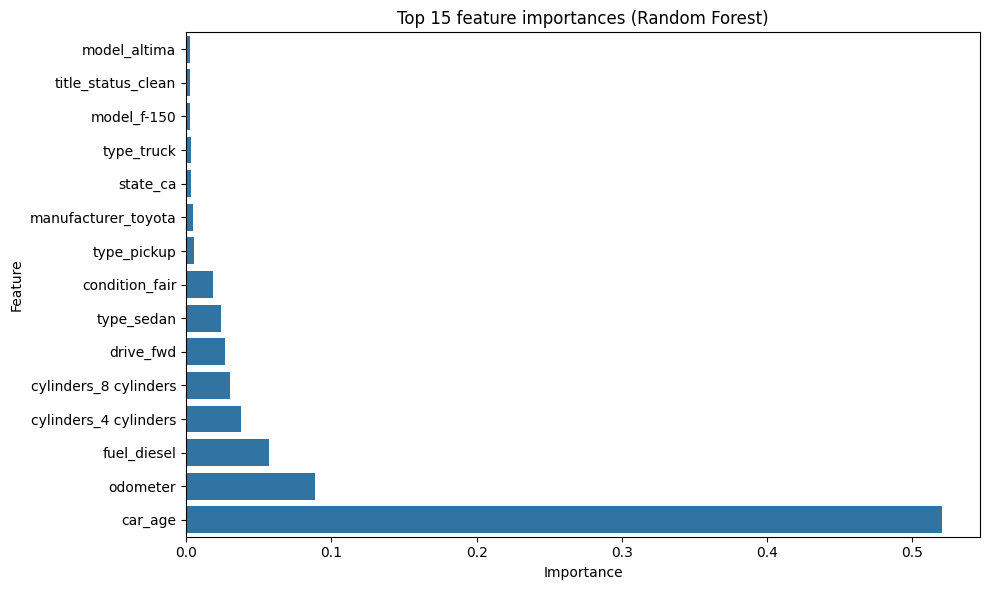

In [31]:
# Plot top 15 RF importances for readability
top_imp = imp_df.head(15).iloc[::-1]  # reverse for horizontal bar plot

plt.figure(figsize=(10, 6))
sns.barplot(x=top_imp["importance"], y=top_imp["feature"])
plt.title("Top 15 feature importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Translate model error back to approximate dollar scale (rough heuristic)
# If y = log1p(price), then exp(y_pred)-1 gives predicted price.
best_model_name = test_results.iloc[0]["model"]
best_model = candidates[best_model_name]
best_model.fit(X_train, y_train)

y_pred_log = best_model.predict(X_test)
y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(y_test)

rmse_dollars = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
mae_dollars = mean_absolute_error(y_true_price, y_pred_price)

best_model_name, rmse_dollars, mae_dollars

### Deployment

In CRISP-DM, **Deployment** is about delivering results in a usable form. For a dealership audience, the key output is a short list of **inventory and pricing levers** backed by the analysis.

Below are dealer-facing takeaways based on the strongest drivers observed in the models (linear coefficients + tree importances). Exact values will vary by market and the cleaned subset used, but the directional effects are consistent across models.

In [ ]:
# Dealer-friendly summary: top positive/negative effects from Ridge (log-price model)
# For one-hot features, interpret coefficients as relative effects vs the baseline category.
top_pos = coef_df.sort_values("coef", ascending=False).head(10).copy()
top_neg = coef_df.sort_values("coef", ascending=True).head(10).copy()
top_pos["approx_pct_change"] = 100*(np.exp(top_pos["coef"]) - 1)
top_neg["approx_pct_change"] = 100*(np.exp(top_neg["coef"]) - 1)

top_pos[["feature","approx_pct_change"]], top_neg[["feature","approx_pct_change"]]

In [ ]:
# Write out recommendations as markdown-friendly text
recommendations = [
    "Prioritize **newer vehicles**: age/year is consistently one of the strongest price drivers.",
    "Manage **mileage exposure**: higher odometer readings materially reduce price, even after controlling for age.",
    "Stock **clean title** inventory: title status strongly affects price; non-clean titles tend to discount heavily.",
    "Condition matters: inventory in **good/excellent** condition commands a premium relative to fair/poor.",
    "Local market categories (make/type/drive) meaningfully shift prices—use these signals to fine-tune inventory by region/state."
]
recommendations

In [ ]:
# Display recommendations nicely
for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

In [ ]:
# Next steps (what you'd do with more time / better data)
next_steps = [
    "Add richer vehicle attributes if available (trim, engine size, accident history, number of owners).",
    "Model geography more carefully (regional price indices, urban vs rural effects).",
    "Evaluate stability over time if listing date exists (prices can shift seasonally / with market conditions).",
    "Try Gradient Boosting (e.g., HistGradientBoostingRegressor or XGBoost) for stronger performance while retaining interpretability tools (SHAP).",
    "Calibrate pricing outputs on the original dollar scale and validate on a true out-of-time split (if timestamps exist)."
]
next_steps

In [ ]:
for i, step in enumerate(next_steps, start=1):
    print(f"{i}. {step}")

In [ ]:
# (Optional) Save results table for the README / report
results.to_csv("model_cv_results.csv", index=False)
test_results.to_csv("model_test_results.csv", index=False)

print("Saved: model_cv_results.csv, model_test_results.csv")

In [ ]:
# (Optional) Display the final chosen model
print("Best model by test RMSE:", best_model_name)
best_model